# A demonstration of CNICA

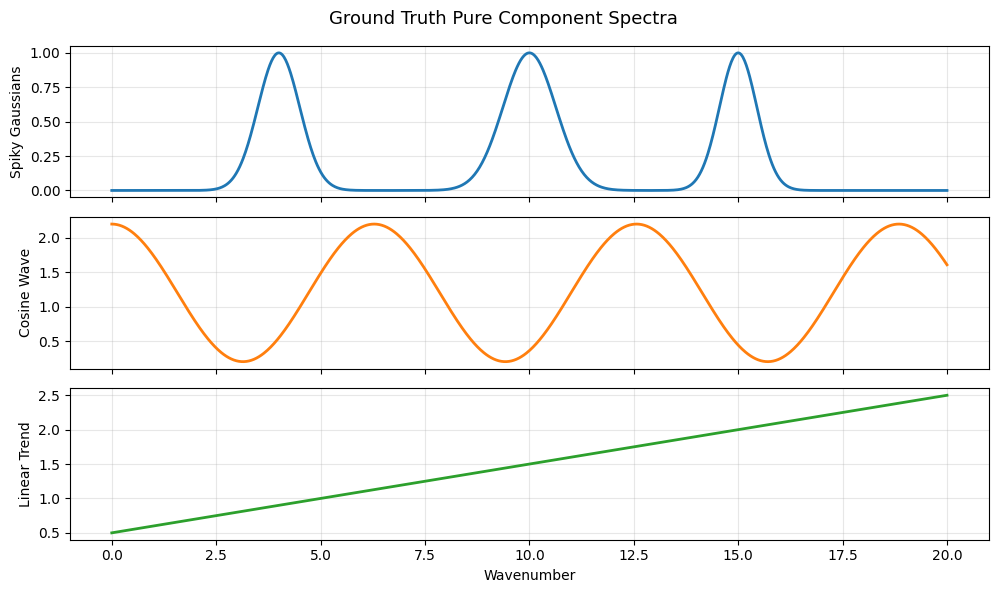

In [1]:
import numpy as np
from cnica import CNICA
from cnica.models import NMFParams, MIOParams
import matplotlib.pyplot as plt

# Ground truth sources representing physically distinct spectral components:
# a peaky signal (e.g. sharp Raman bands), a smooth oscillatory signal
# (e.g. interference fringes), and a linear background (e.g. fluorescence)
n_wave = 1000
n_channels = 100
n_components = 3
x = np.linspace(0, 20, n_wave)

s1 = np.exp(-(x - 4)**2 / 0.5) + np.exp(-(x - 10)**2 / 0.8) + np.exp(-(x - 15)**2 / 0.4)
s2 = np.cos(x) + 1.2
s3 = 0.1 * x + 0.5
S_true = np.vstack([s1, s2, s3])

fig, axes = plt.subplots(n_components, 1, figsize=(10, 6), sharex=True)
names = ["Spiky Gaussians", "Cosine Wave", "Linear Trend"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for i, ax in enumerate(axes):
    ax.plot(x, S_true[i], color=colors[i], lw=2)
    ax.set_ylabel(names[i], fontsize=10)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Wavenumber")
fig.suptitle("Ground Truth Pure Component Spectra", fontsize=13)
plt.tight_layout()
plt.show()

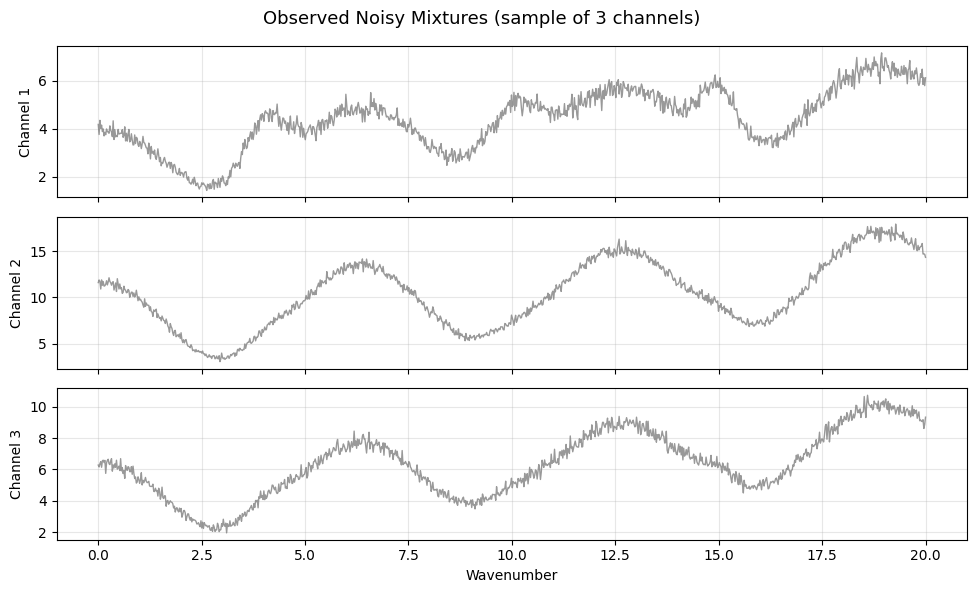

In [2]:
# Generate a random non-negative mixing matrix C of shape (n_channels, n_components)
# representing concentration profiles — e.g. how much of each species is present
# at each time point or spatial location
np.random.seed(42)
C_true = np.random.gamma(shape=2.0, scale=1.0, size=(n_channels, n_components))

# The observed data matrix D = C @ S has shape (n_channels, n_wave)
# Each row is a mixed spectrum observed at one channel
D_clean = C_true @ S_true

# Add Poisson noise to simulate photon-counting detector noise
noise_scale = 100
D_noisy = np.random.poisson(D_clean * noise_scale) / noise_scale

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(x, D_noisy[i], color="gray", lw=1, alpha=0.8)
    ax.set_ylabel(f"Channel {i+1}", fontsize=10)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Wavenumber")
fig.suptitle("Observed Noisy Mixtures (sample of 3 channels)", fontsize=13)
plt.tight_layout()
plt.show()

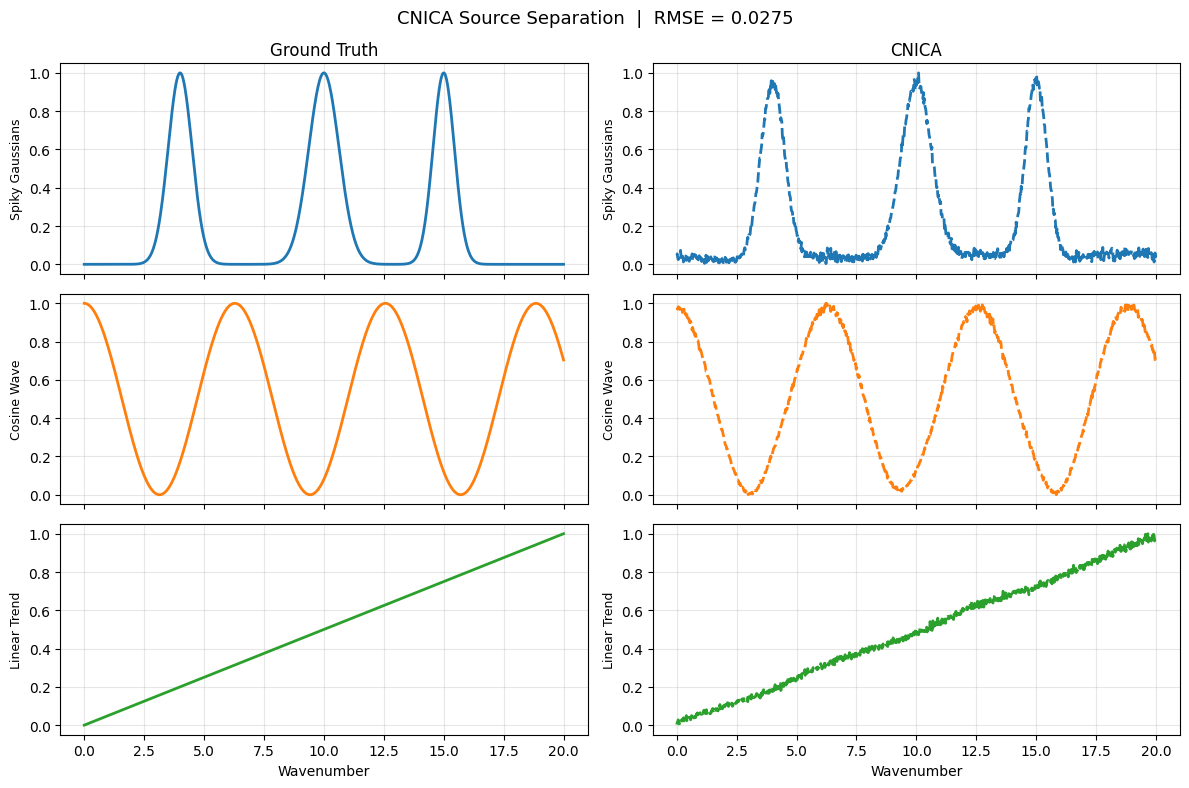

RMSE vs ground truth: 0.0275


In [3]:
from sklearn.preprocessing import MinMaxScaler

# Run CNICA with Kullback-Leibler NMF initialization, which is well-suited
# to Poisson noise, followed by Riemannian MI minimization using the 0th
# and 1st order derivative covariances
model = CNICA(
    n_components=n_components,
    nmf_params=NMFParams(
        init="nndsvd",
        max_iter=10000,
        tol=1e-5
    ),
    mio_params=MIOParams(
        params=(True, True, False),
        lam=100.0,
        max_outer_loop_iters=10,
        max_inner_loop_iters=1000
    )
)

S_est = model.fit_transform(D_noisy)
C_est = model.C_

# Normalize to [0, 1] for visual comparison — CNICA recovers components
# up to a positive scaling ambiguity
scaler = MinMaxScaler()
S_true_norm = scaler.fit_transform(S_true.T).T
S_est_norm = scaler.fit_transform(S_est.T).T

# Match estimated components to ground truth by maximum correlation
def match_components(S_ref, S_est):
    reordered = np.zeros_like(S_est)
    used = set()
    for i in range(S_ref.shape[0]):
        corrs = [
            np.corrcoef(S_ref[i], S_est[j])[0, 1] if j not in used else -np.inf
            for j in range(S_est.shape[0])
        ]
        best = int(np.argmax(corrs))
        reordered[i] = S_est[best]
        used.add(best)
    return reordered

S_est_matched = match_components(S_true_norm, S_est_norm)

fig, axes = plt.subplots(n_components, 2, figsize=(12, 8), sharex=True)
col_titles = ["Ground Truth", "CNICA"]
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=12)

for i in range(n_components):
    axes[i, 0].plot(x, S_true_norm[i], color=colors[i], lw=2)
    axes[i, 1].plot(x, S_est_matched[i], color=colors[i], lw=2, linestyle="--")
    for j in range(2):
        axes[i, j].set_ylabel(names[i], fontsize=9)
        axes[i, j].grid(alpha=0.3)

axes[-1, 0].set_xlabel("Wavenumber")
axes[-1, 1].set_xlabel("Wavenumber")

rmse = np.sqrt(np.mean((S_true_norm - S_est_matched) ** 2))
fig.suptitle(f"CNICA Source Separation  |  RMSE = {rmse:.4f}", fontsize=13)
plt.tight_layout()
plt.show()

print(f"RMSE vs ground truth: {rmse:.4f}")